In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PERIOD = 25
TRAIN_DAYS = 20
TEST_DAYS = 5
TIME = 24   # if monthly --> 12, else if hourly --> 24
FEATURES = 7
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")

Tensor dimensions: 25 x 24 x 7


In [3]:
df = pd.read_csv("datasets/ETTh1.csv")

df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [4]:
df.shape

(17420, 8)

In [5]:
df.shape, df.dtypes, df.isnull().sum()

((17420, 8),
 date     object
 HUFL    float64
 HULL    float64
 MUFL    float64
 MULL    float64
 LUFL    float64
 LULL    float64
 OT      float64
 dtype: object,
 date    0
 HUFL    0
 HULL    0
 MUFL    0
 MULL    0
 LUFL    0
 LULL    0
 OT      0
 dtype: int64)

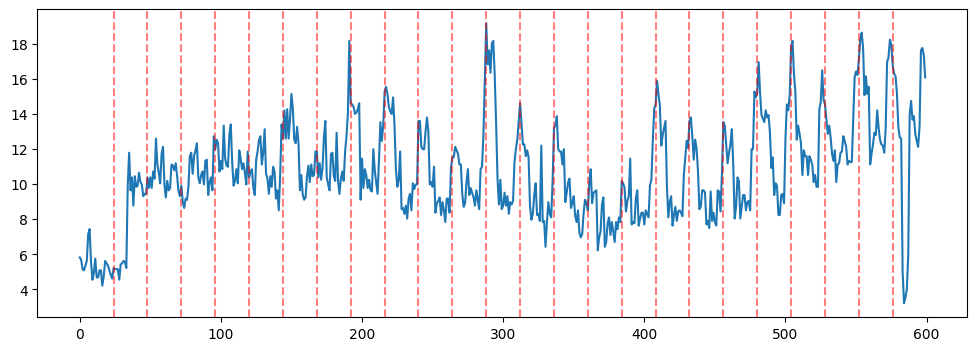

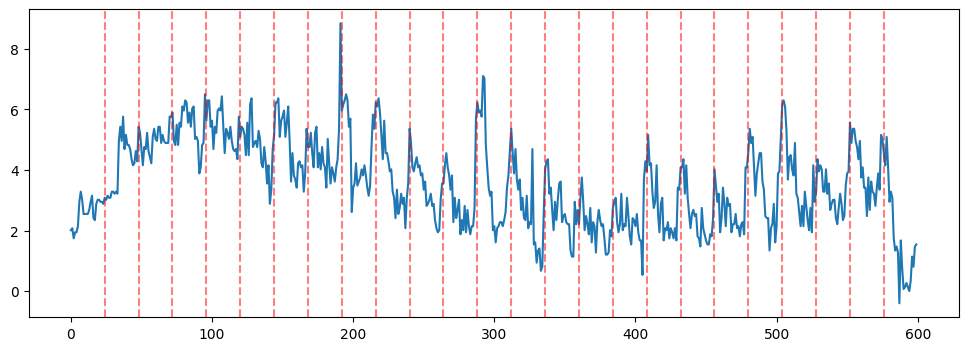

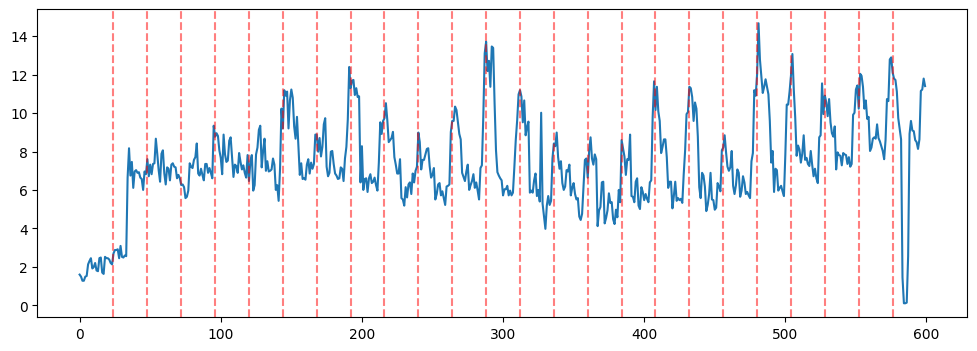

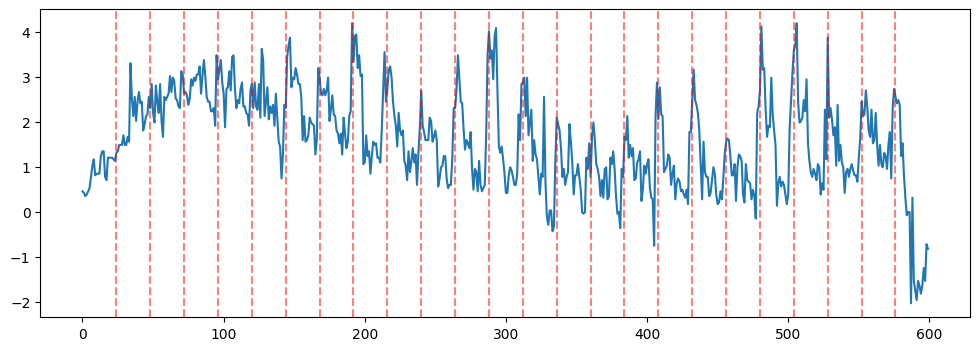

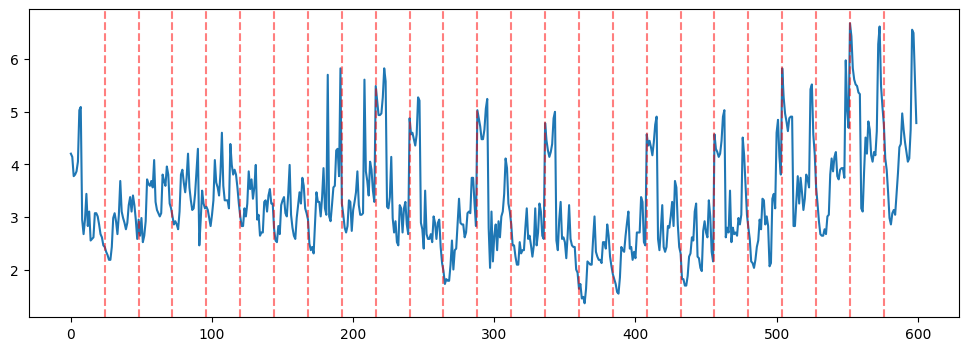

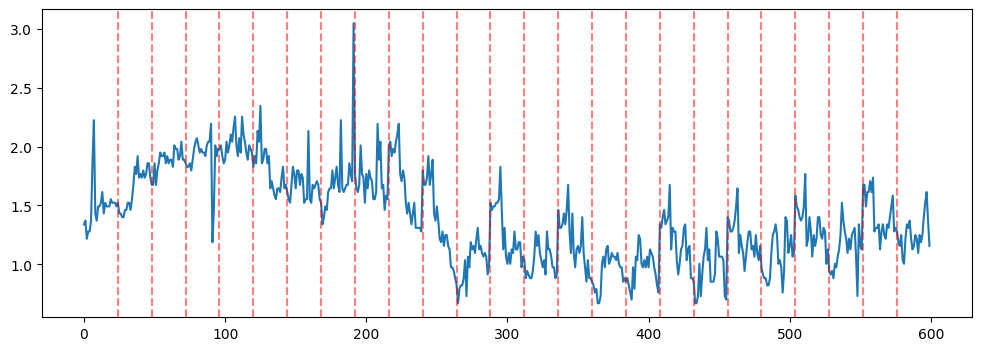

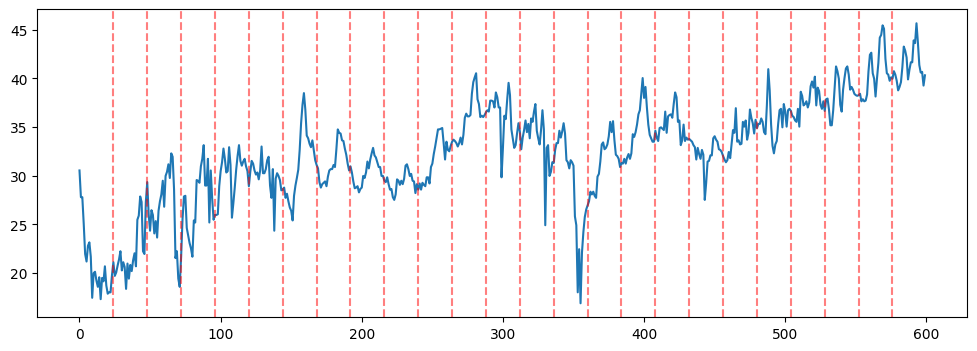

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.to_list()

for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df[col][:PERIOD*TIME].values)
    for i in range(1, PERIOD):
        plt.axvline(x=i*TIME, color='r', linestyle='--', alpha=0.5)


### Smoothing using rolling mean

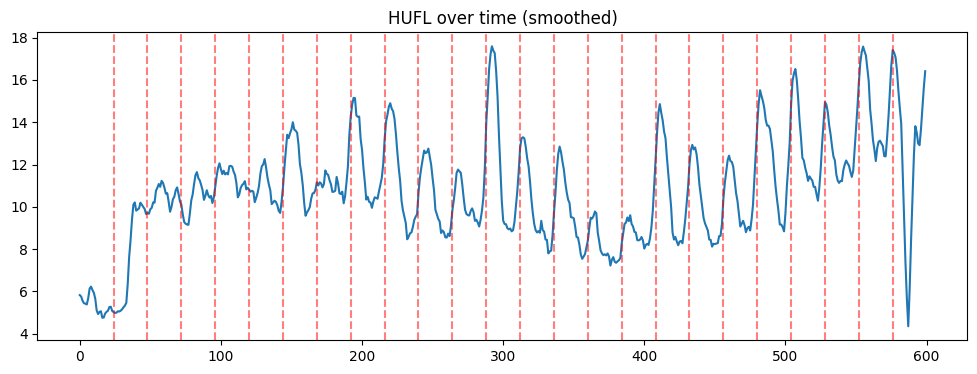

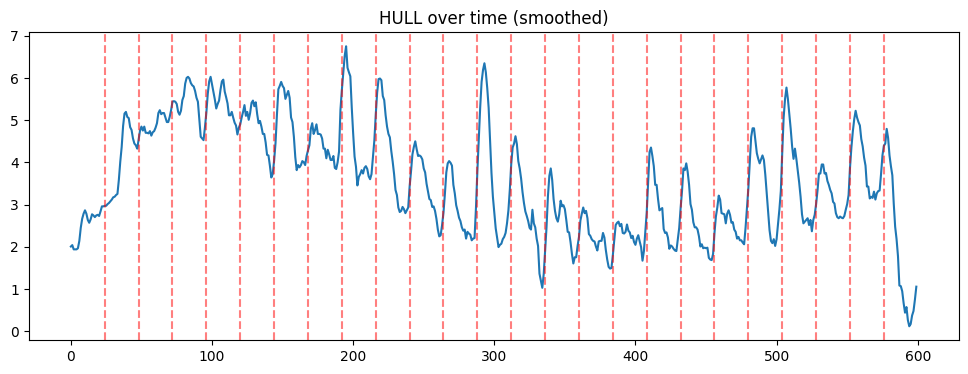

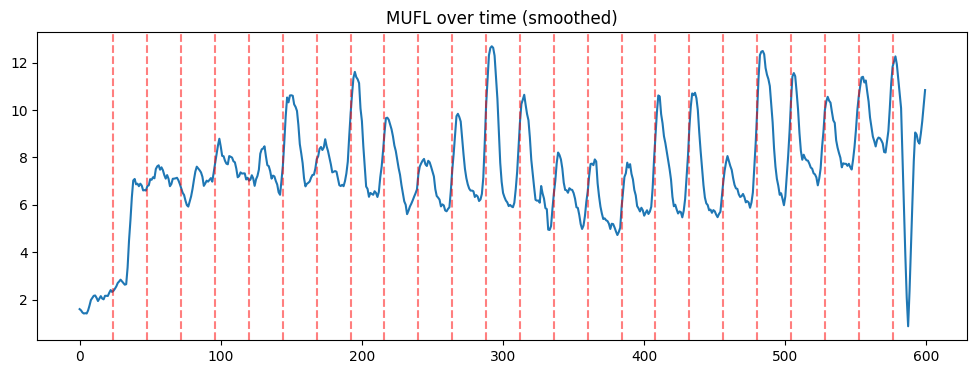

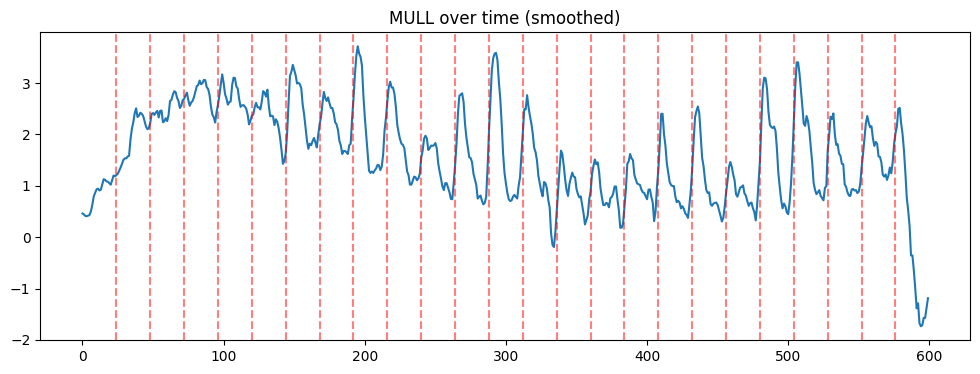

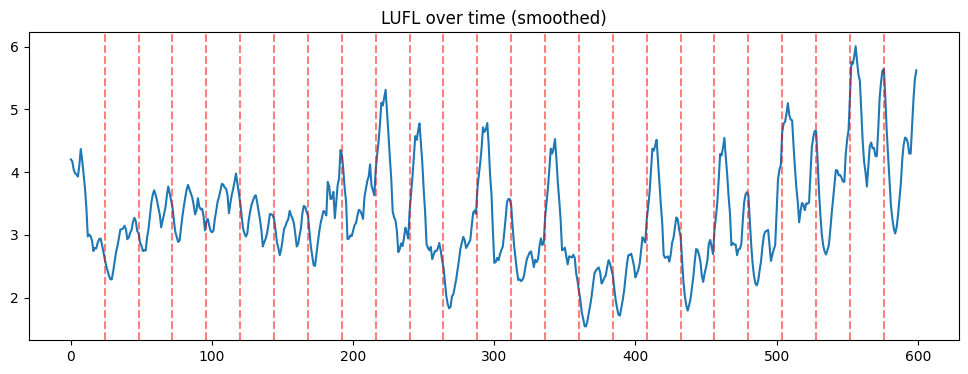

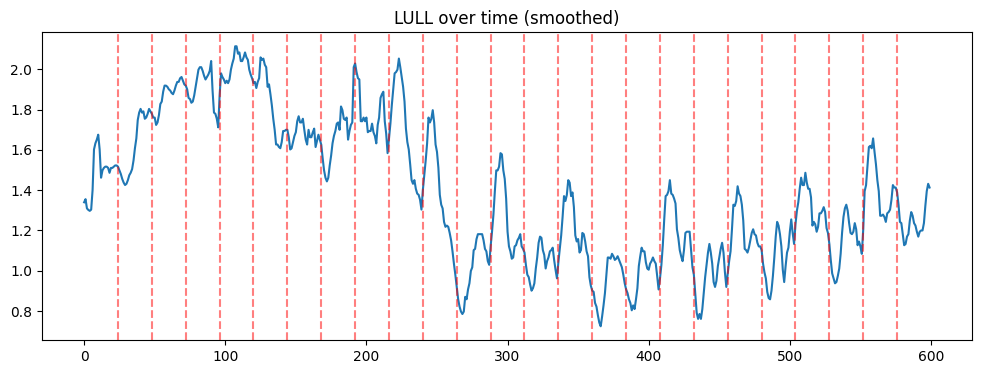

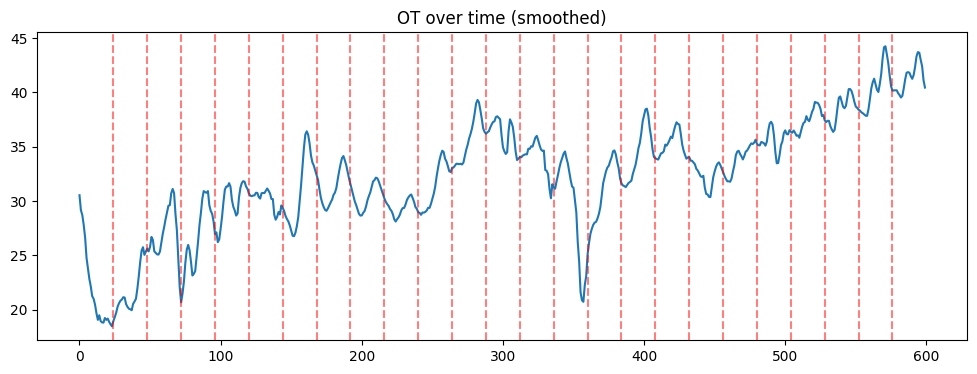

In [7]:
# make each numeric column smooth by rolling mean
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

for col in numeric_cols:
    plt.figure(figsize=(12, 4))
    plt.plot(df[col][:PERIOD*TIME])
    for i in range(1, PERIOD):
        plt.axvline(x=i*TIME, color='r', linestyle='--', alpha=0.5)
    plt.title(f"{col} over time (smoothed)")

In [8]:
data = df[numeric_cols][:PERIOD*TIME].values

tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 24, 7)

In [9]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 24, 7)
Test tensor shape: (5, 24, 7)


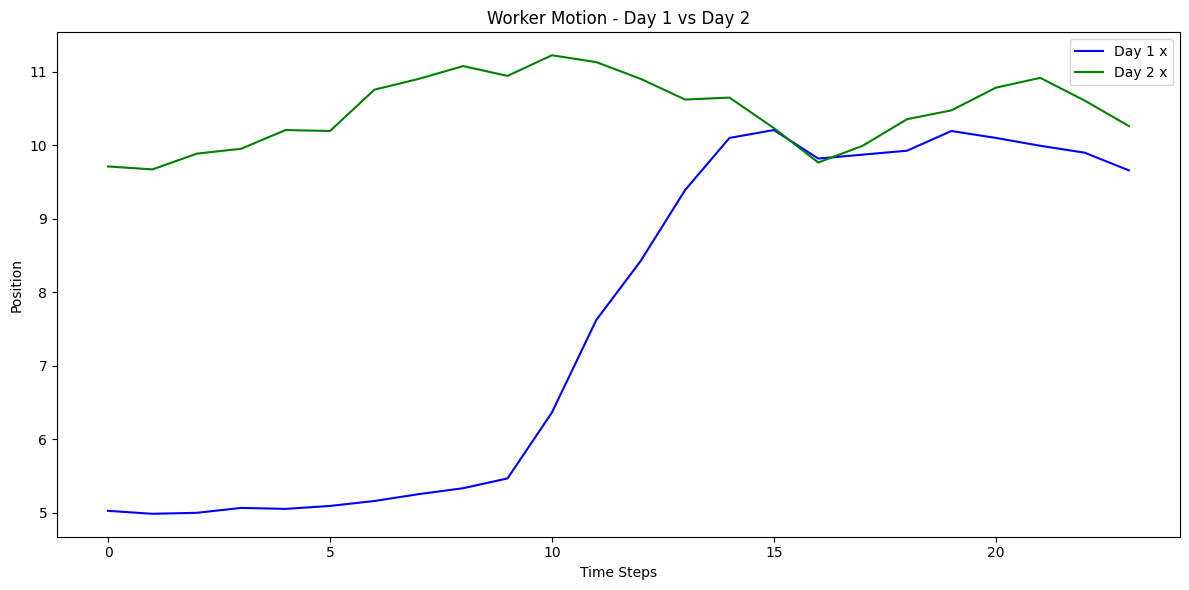

In [10]:
train_day_1 = tensor[1, :, :]
train_day_2 = tensor[2, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [11]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (24, 2)
Feature factors shape: (7, 2)


In [12]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 24, 7)
Reconstructed tensor shape: (20, 24, 7)


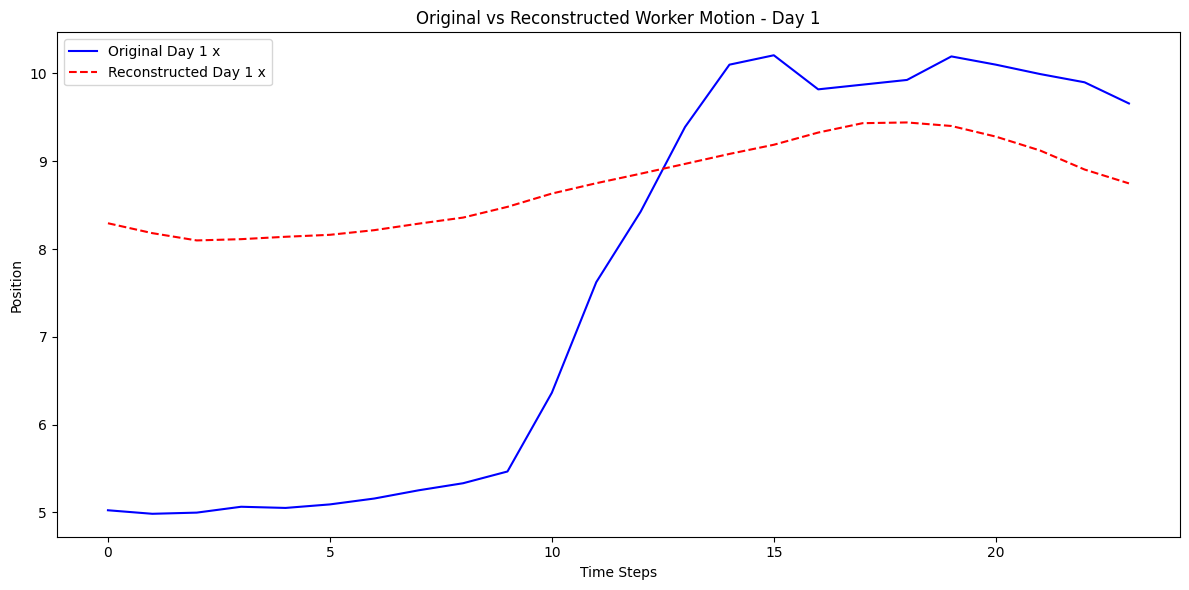

In [13]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [14]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

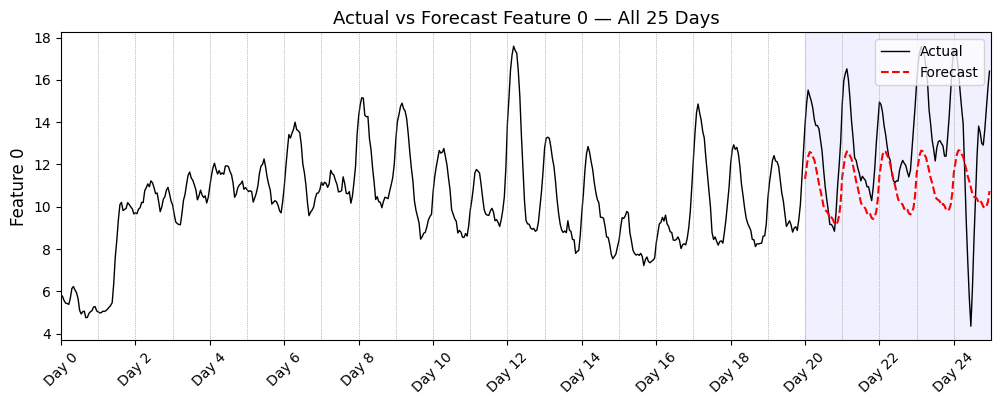

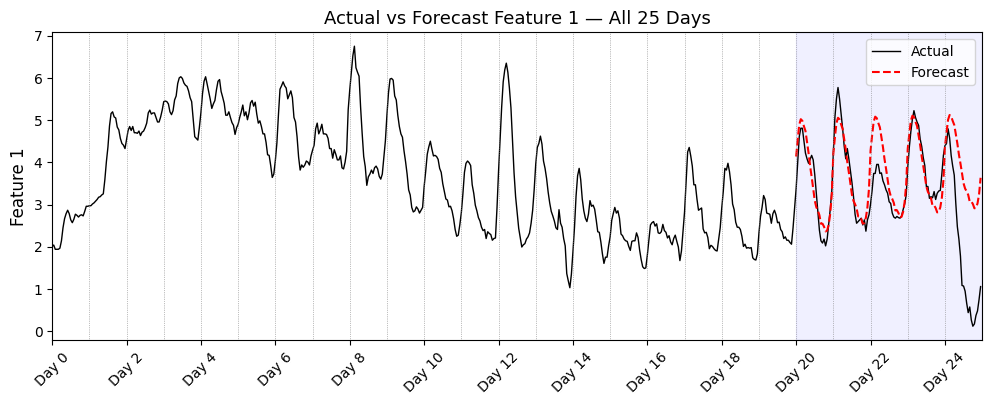

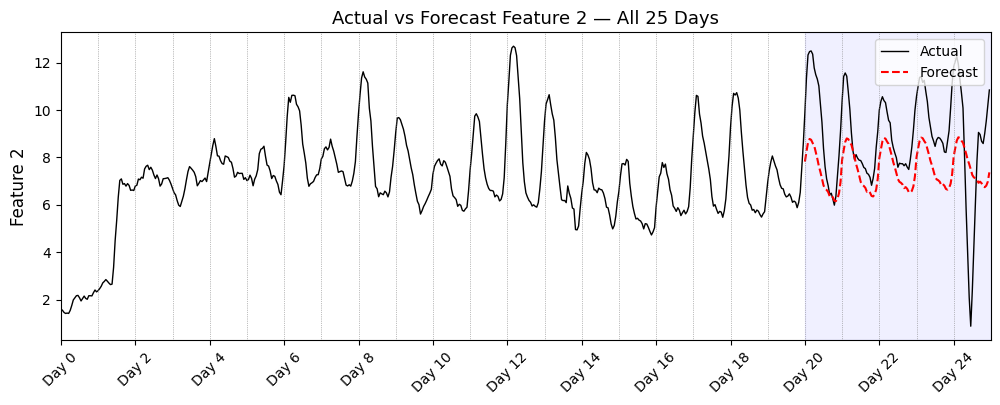

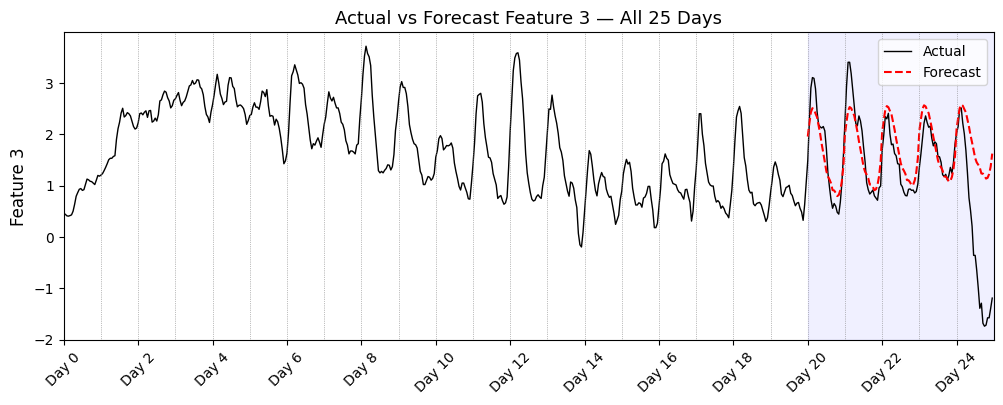

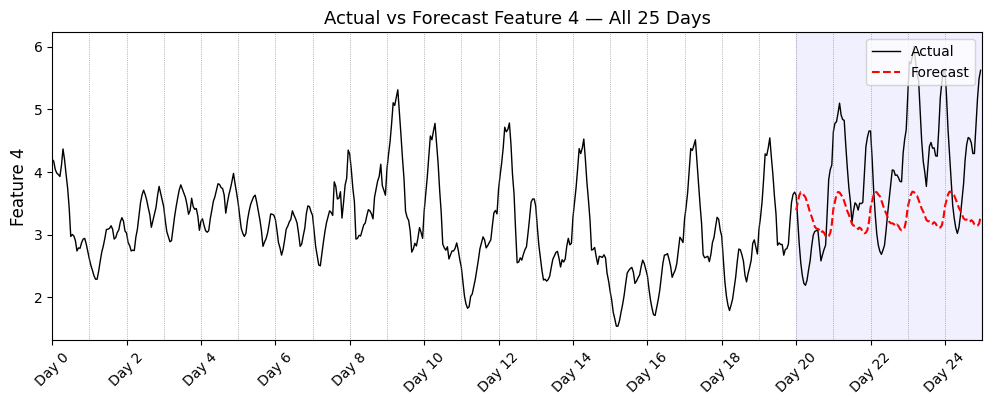

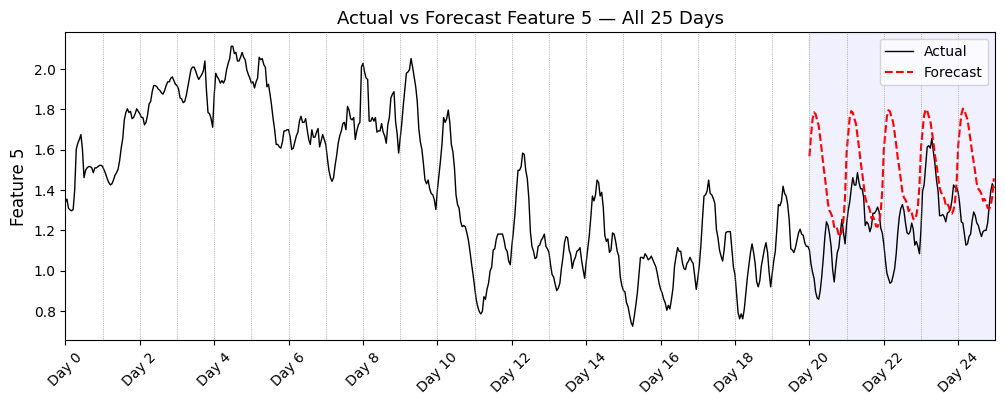

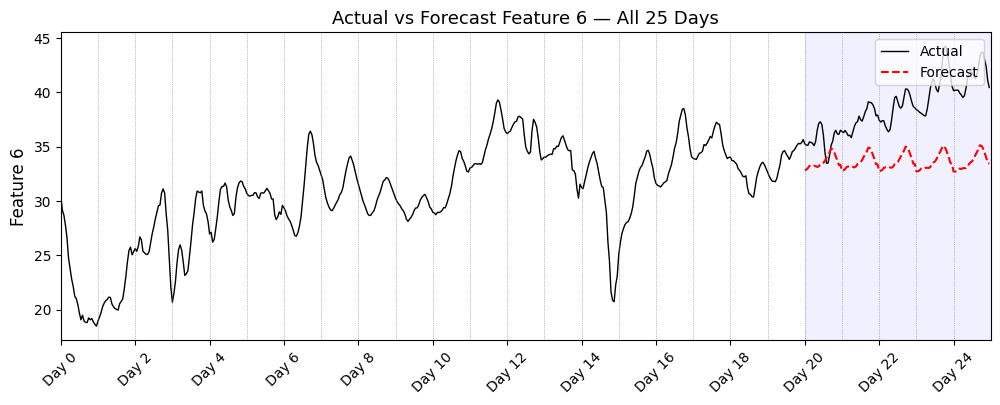

In [15]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

# plt.figure(figsize=(32, 8))

# plt.subplot(4, 1, 1)
# plt.plot(x, full_series[:, 0], 'k-', lw=1, label='Actual G')
# plt.plot(x_forecast, forecast_series[:, 0], 'r--', lw=1.5, label='Forecast G')
# for d in range(1, PERIOD + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('G', fontsize=12)
# plt.title('Actual vs Forecast G (Conductance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

# plt.subplot(4, 1, 2)
# plt.plot(x, full_series[:, 1], 'k-', lw=1, label='Actual B')
# plt.plot(x_forecast, forecast_series[:, 1], 'r--', lw=1.5, label='Forecast B')
# for d in range(1, PERIOD + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('B', fontsize=12)
# plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

# plt.subplot(4, 1, 3)
# plt.plot(x, full_series[:, 2], 'k-', lw=1, label='Actual B')
# plt.plot(x_forecast, forecast_series[:, 2], 'r--', lw=1.5, label='Forecast B')
# for d in range(1, PERIOD + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('B', fontsize=12)
# plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

# plt.subplot(4, 1, 4)
# plt.plot(x, full_series[:, 3], 'k-', lw=1, label='Actual B')
# plt.plot(x_forecast, forecast_series[:, 3], 'r--', lw=1.5, label='Forecast B')
# for d in range(1, PERIOD + 1):
#     plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
# plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
# plt.xticks(np.arange(0, T + 1, 2 * TIME),
#            [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
# plt.xlim(0, T)
# plt.ylabel('B', fontsize=12)
# plt.title('Actual vs Forecast B (Susceptance) — All 27 Days', fontsize=13)
# plt.legend(loc='upper right')

# # plt.xlabel('Time Steps', fontsize=12)
# # plt.tight_layout()
# # plt.show()

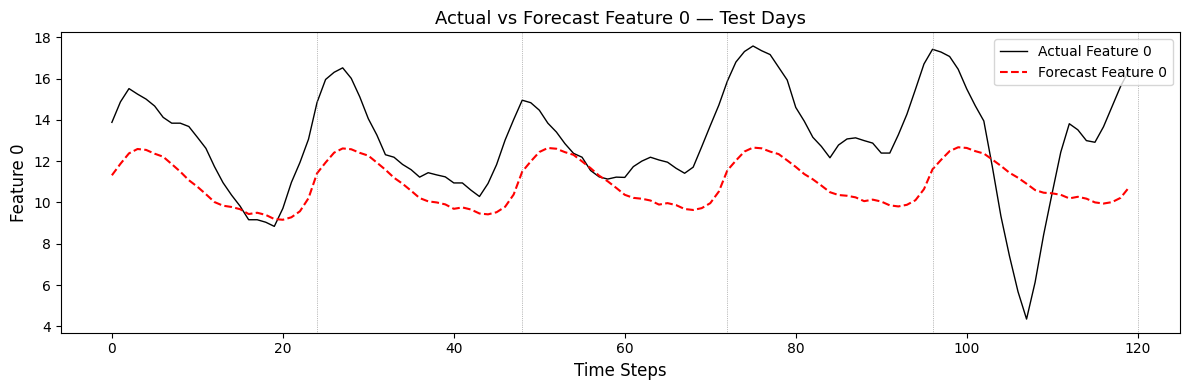

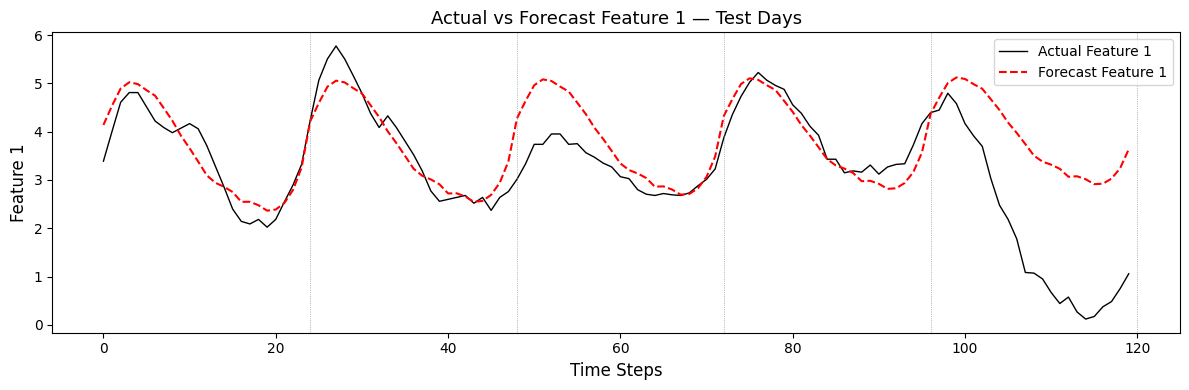

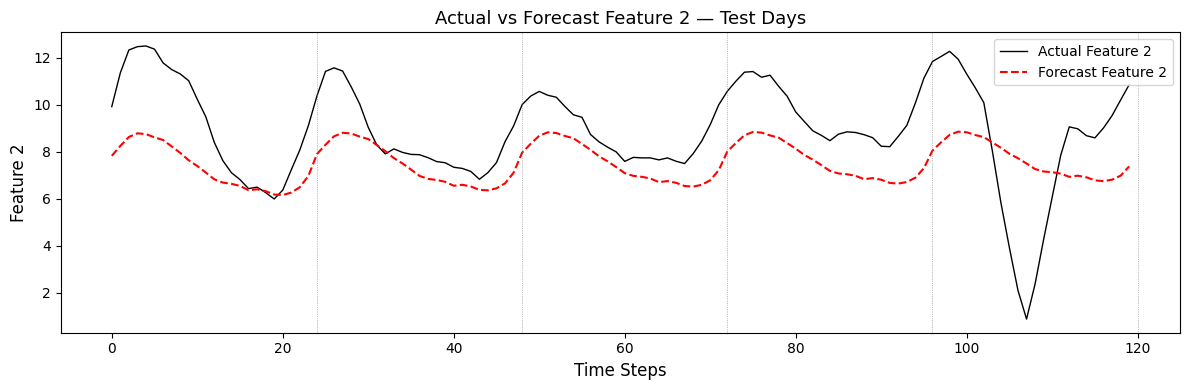

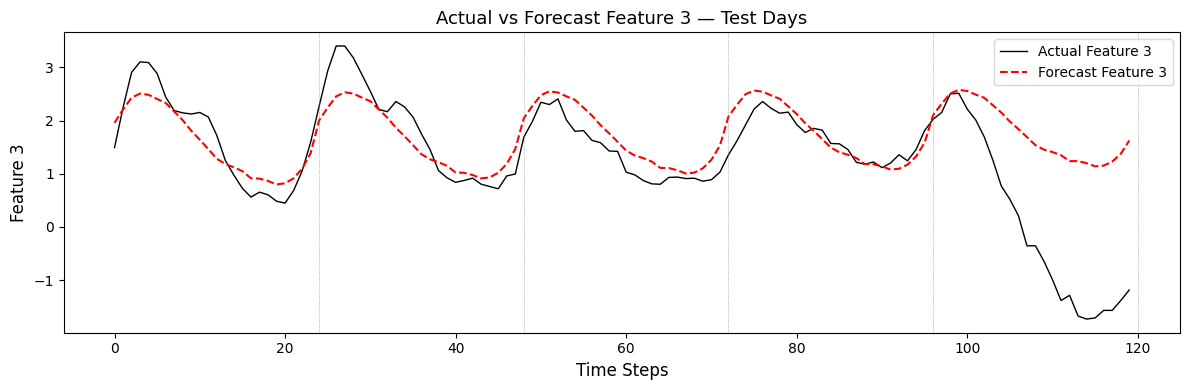

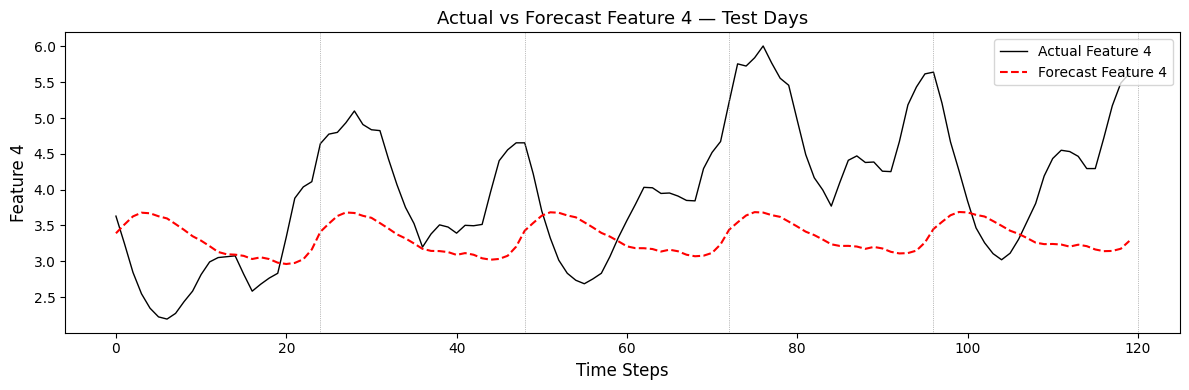

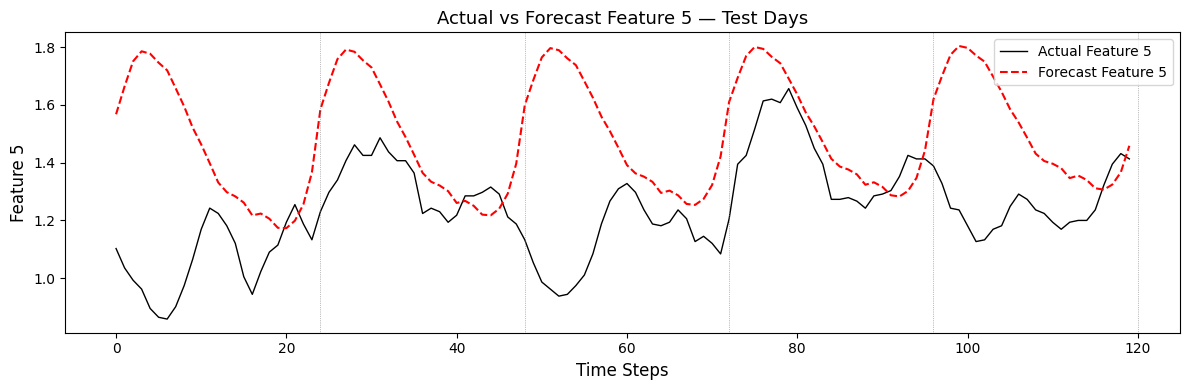

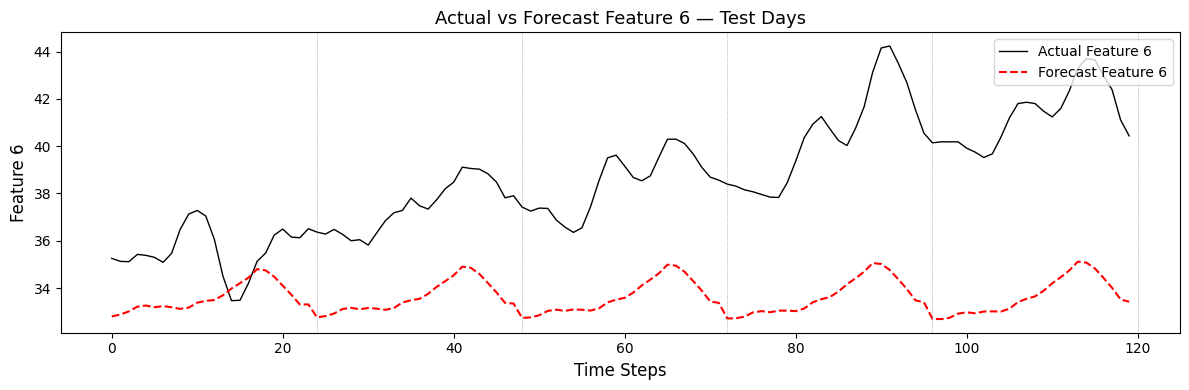

In [16]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [17]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((480, 7), (120, 7))

In [18]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mse_scores.append(mse)
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    mae_scores.append(mae)
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print(f"Average R²: {np.mean(r2_scores):.4f}")
print(f"Average MSE: {np.mean(mse_scores):.4f}")
print(f"Average MAE: {np.mean(mae_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")

Feature 0 R²: -0.3633, MSE: 8.5952, MAE: 2.4958, RMSE: 2.9318
Feature 1 R²: 0.3174, MSE: 1.0797, MAE: 0.6656, RMSE: 1.0391
Feature 2 R²: -0.1132, MSE: 4.9441, MAE: 1.8598, RMSE: 2.2235
Feature 3 R²: 0.2954, MSE: 0.9061, MAE: 0.5760, RMSE: 0.9519
Feature 4 R²: -0.4986, MSE: 1.3015, MAE: 0.9608, RMSE: 1.1408
Feature 5 R²: -3.6472, MSE: 0.1294, MAE: 0.2658, RMSE: 0.3597
Feature 6 R²: -3.9865, MSE: 30.1986, MAE: 5.0311, RMSE: 5.4953
Average R²: -1.1423
Average MSE: 6.7364
Average MAE: 1.6936
Average RMSE: 2.0203
